# Model Calibration Fixes: Evaluating LightGBM Probability Estimation

**Problem:** The LightGBM model predicts ~90% probability for contracts that should be ~35-40%
(e.g., CPI inflation > 2.4% for Feb 2026). The Cleveland Fed nowcast puts this at 2.41% YoY,
meaning the true probability of "above 2.4%" is roughly 35-40% — not 90%.

This notebook diagnoses the root cause and evaluates 4 fixes:

1. **Training Data Diagnostics** — Is the data sufficient and balanced? Which features are actually populated?
2. **Platt Scaling vs Isotonic Calibration** — Is isotonic overfitting on limited data?
3. **Feature Importance & Price Leakage** — Is `yes_price` dominating the model?
4. **Per-Bin Calibration Analysis** — Where exactly does calibration break down?

Each fix is evaluated using Brier score, ECE, and reliability diagrams on a temporal test set.

---

In [1]:
import csv
import pickle
import tempfile
from datetime import UTC, datetime

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression

from arbiter.models.features import SPEC
from arbiter.training.dataset import temporal_split
from arbiter.training.evaluate import (
    brier_score,
    calibration_curve,
    expected_calibration_error,
)
from arbiter.training.historical import backtest_from_csv

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

COLORS = {
    "primary": "#2563eb",
    "secondary": "#7c3aed",
    "accent": "#059669",
    "warning": "#d97706",
    "danger": "#dc2626",
    "muted": "#6b7280",
    "light": "#e5e7eb",
}

# LightGBM params (matching arbiter/training/train.py)
LGBM_PARAMS = {
    "objective": "binary",
    "metric": "binary_logloss",
    "verbosity": -1,
    "num_leaves": 31,
    "learning_rate": 0.05,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "min_child_samples": 10,
}
NUM_ROUNDS = 300
EARLY_STOPPING_ROUNDS = 30

In [ ]:
DATA_PATH = "../data/training.csv"

# Load into numpy arrays (matching train.py _load_data logic)
rows, lab, ts = [], [], []
with open(DATA_PATH) as f:
    reader = csv.DictReader(f)
    for i, row in enumerate(reader):
        rows.append([float(row.get(name, "nan")) for name in SPEC.names])
        lab.append(float(row["outcome"]))
        ts.append(float(row.get("timestamp", i)))

features = np.array(rows, dtype=np.float64)
labels = np.array(lab, dtype=np.float64)
timestamps = np.array(ts, dtype=np.float64)

# Also load as DataFrame for diagnostics
df = pd.read_csv(DATA_PATH)

print(f"Dataset: {len(features):,} samples x {features.shape[1]} features")
pos, neg = int((labels == 1).sum()), int((labels == 0).sum())
print(f"Label distribution: {labels.mean():.3f} positive rate ({pos:,} YES / {neg:,} NO)")

In [3]:
# Temporal split — shared across all experiments
splits = temporal_split(features, labels, timestamps)
x_train, y_train = splits["train"]
x_val, y_val = splits["val"]
x_test, y_test = splits["test"]

print(f"Train: {len(x_train):,}  Val: {len(x_val):,}  Test: {len(x_test):,}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Val positive rate:   {y_val.mean():.3f}")
print(f"Test positive rate:  {y_test.mean():.3f}")

Train: 106,728  Val: 22,870  Test: 22,870
Train positive rate: 0.479
Val positive rate:   0.443
Test positive rate:  0.490


---
## Fix 1: Training Data Diagnostics

Before changing the model, we need to understand the data. Key questions:
- Is 152K samples enough for 16 features? (Yes, but effective dimensionality matters)
- Is the class balance reasonable?
- How many features are actually populated vs NaN?
- What's the temporal coverage?

In [ ]:
# Temporal range
ts_min = datetime.fromtimestamp(timestamps.min(), tz=UTC)
ts_max = datetime.fromtimestamp(timestamps.max(), tz=UTC)
span_days = (ts_max - ts_min).days

start = ts_min.strftime("%Y-%m-%d")
end = ts_max.strftime("%Y-%m-%d")
print(f"Temporal range: {start} to {end} ({span_days} days)")
print(f"Total samples: {len(df):,}")
print(f"Positive (outcome=1): {(labels == 1).sum():,} ({labels.mean():.1%})")
print(f"Negative (outcome=0): {(labels == 0).sum():,} ({1 - labels.mean():.1%})")

if "contract_id" in df.columns:
    print(f"\nUnique contracts: {df['contract_id'].nunique()}")
else:
    print("\nUnique contracts: N/A (no contract_id column)")

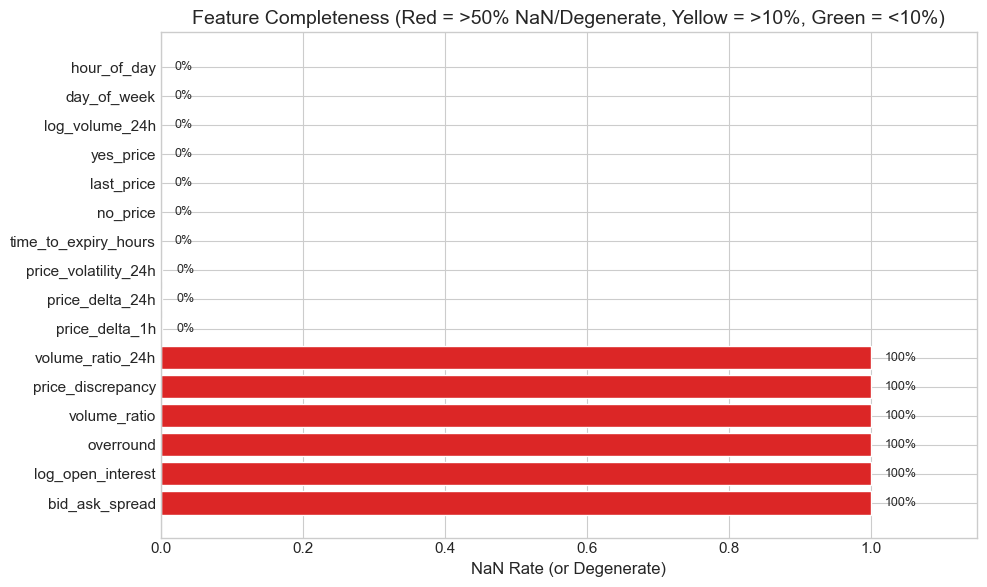


Effective features (>50% populated): 11 of 16
Cross-platform features (price_discrepancy, volume_ratio) are 100% NaN —
training data comes from single-platform candle history, not live cross-platform snapshots.
'overround' is always 0.0 because candle data sets no_price = 1 - yes_price.


In [5]:
# Feature completeness — NaN rate per feature
nan_rates = pd.DataFrame({
    "Feature": SPEC.names,
    "NaN Rate": [np.isnan(features[:, i]).mean() for i in range(features.shape[1])],
    "Non-NaN Samples": [int((~np.isnan(features[:, i])).sum()) for i in range(features.shape[1])],
})

# Check for degenerate features (zero variance)
for i, name in enumerate(SPEC.names):
    col = features[:, i]
    valid = col[~np.isnan(col)]
    if len(valid) > 0 and np.std(valid) < 1e-10:
        nan_rates.loc[nan_rates["Feature"] == name, "NaN Rate"] = 1.0  # Mark as useless
        print(f"WARNING: '{name}' has zero variance (constant={valid[0]:.4f}) — degenerate feature")

nan_rates = nan_rates.sort_values("NaN Rate", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = [
    COLORS["danger"] if r > 0.5 else COLORS["warning"] if r > 0.1 else COLORS["accent"]
    for r in nan_rates["NaN Rate"]
]
ax.barh(nan_rates["Feature"], nan_rates["NaN Rate"], color=colors_bar, edgecolor="white")
ax.set_xlabel("NaN Rate (or Degenerate)")
ax.set_title("Feature Completeness (Red = >50% NaN/Degenerate, Yellow = >10%, Green = <10%)")
ax.set_xlim(0, 1.15)
for i, (_, row) in enumerate(nan_rates.iterrows()):
    ax.text(row["NaN Rate"] + 0.02, i, f"{row['NaN Rate']:.0%}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

effective_features = sum(
    1 for i in range(features.shape[1]) if np.isnan(features[:, i]).mean() < 0.5
)
print(f"\nEffective features (>50% populated): {effective_features} of {features.shape[1]}")
print("Cross-platform features (price_discrepancy, volume_ratio) are 100% NaN —")
print("training data comes from single-platform candle history, not live cross-platform snapshots.")
print("'overround' is always 0.0 because candle data sets no_price = 1 - yes_price.")

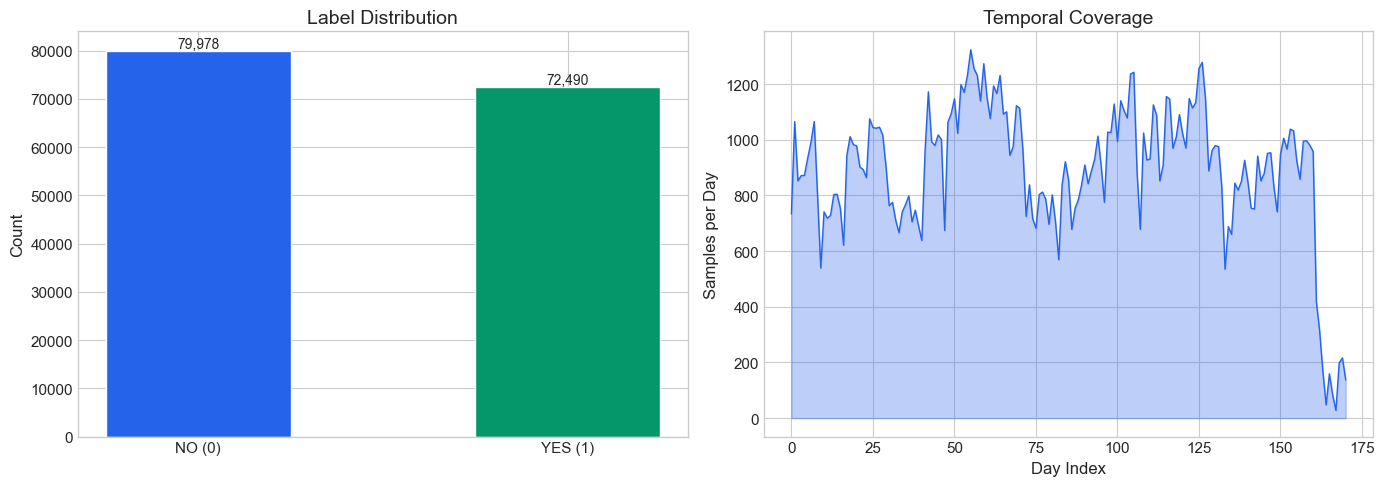

Median samples per day: 930
Days with data: 171


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label distribution
counts = [(labels == 0).sum(), (labels == 1).sum()]
axes[0].bar(["NO (0)", "YES (1)"], counts, color=[COLORS["primary"], COLORS["accent"]],
            edgecolor="white", width=0.5)
axes[0].set_ylabel("Count")
axes[0].set_title("Label Distribution")
for i, c in enumerate(counts):
    axes[0].text(i, c + 500, f"{c:,}", ha="center", fontsize=10)

# Temporal coverage: samples per day
dates = pd.to_datetime(timestamps, unit="s", utc=True)
daily_counts = pd.Series(dates).dt.date.value_counts().sort_index()
axes[1].fill_between(range(len(daily_counts)), daily_counts.values,
                     alpha=0.3, color=COLORS["primary"])
axes[1].plot(range(len(daily_counts)), daily_counts.values,
             color=COLORS["primary"], linewidth=1)
axes[1].set_xlabel("Day Index")
axes[1].set_ylabel("Samples per Day")
axes[1].set_title("Temporal Coverage")

plt.tight_layout()
plt.show()

print(f"Median samples per day: {daily_counts.median():.0f}")
print(f"Days with data: {len(daily_counts)}")

---
## Fix 2: Platt Scaling vs Isotonic Calibration

**Hypothesis:** Isotonic regression (non-parametric, N free parameters) may overfit on the
validation set, creating a step function that warps moderate probabilities toward extremes.
Platt scaling (logistic regression on raw predictions, 2 parameters) should be more robust.

We train the same LightGBM model and compare three calibration approaches:
1. **Isotonic** — current production (`IsotonicRegression(out_of_bounds="clip")`)
2. **Platt** — `LogisticRegression` fitted on raw booster predictions
3. **Uncalibrated** — raw LightGBM output (control)

In [7]:
# Train baseline LightGBM (same as train.py)
train_data = lgb.Dataset(x_train, label=y_train)
val_data = lgb.Dataset(x_val, label=y_val, reference=train_data)

booster = lgb.train(
    LGBM_PARAMS,
    train_data,
    num_boost_round=NUM_ROUNDS,
    valid_sets=[val_data],
    callbacks=[
        lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
        lgb.log_evaluation(50),
    ],
)

val_raw = booster.predict(x_val)
test_raw = booster.predict(x_test)

print(f"Best iteration: {booster.best_iteration}")
print(f"Raw predictions — val range: [{val_raw.min():.4f}, {val_raw.max():.4f}]")
print(f"Raw predictions — test range: [{test_raw.min():.4f}, {test_raw.max():.4f}]")

[50]	valid_0's binary_logloss: 0.590107
Best iteration: 25
Raw predictions — val range: [0.1450, 0.8378]
Raw predictions — test range: [0.1450, 0.8378]


In [8]:
# Fit three calibration approaches

# 1. Isotonic (current production)
isotonic = IsotonicRegression(out_of_bounds="clip")
isotonic.fit(val_raw, y_val)
val_isotonic = isotonic.predict(val_raw)
test_isotonic = isotonic.predict(test_raw)

# 2. Platt scaling (LogisticRegression on raw predictions)
platt = LogisticRegression()
platt.fit(val_raw.reshape(-1, 1), y_val)
val_platt = platt.predict_proba(val_raw.reshape(-1, 1))[:, 1]
test_platt = platt.predict_proba(test_raw.reshape(-1, 1))[:, 1]

# 3. Uncalibrated (raw LightGBM output)
val_uncal = val_raw
test_uncal = test_raw

# Compare metrics
methods = {
    "Uncalibrated": (val_uncal, test_uncal),
    "Isotonic (current)": (val_isotonic, test_isotonic),
    "Platt Scaling": (val_platt, test_platt),
}

results = []
for name, (val_pred, test_pred) in methods.items():
    results.append({
        "Method": name,
        "Val Brier": f"{brier_score(val_pred, y_val):.4f}",
        "Test Brier": f"{brier_score(test_pred, y_test):.4f}",
        "Val ECE": f"{expected_calibration_error(val_pred, y_val):.4f}",
        "Test ECE": f"{expected_calibration_error(test_pred, y_test):.4f}",
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Method Val Brier Test Brier Val ECE Test ECE
      Uncalibrated    0.1763     0.2032  0.0999   0.1747
Isotonic (current)    0.1462     0.1659  0.0000   0.1618
     Platt Scaling    0.1677     0.1901  0.0545   0.1133


In [ ]:
# Reliability diagrams — one per calibration method
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

method_colors = [COLORS["muted"], COLORS["primary"], COLORS["accent"]]
for ax, (name, (_, test_pred)), color in zip(
    axes, methods.items(), method_colors, strict=True
):
    mean_pred, frac_pos = calibration_curve(test_pred, y_test, n_bins=10)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfect calibration")
    ax.plot(mean_pred, frac_pos, "o-", color=color, linewidth=2, markersize=8, label=name)
    ax.fill_between(mean_pred, mean_pred, frac_pos, alpha=0.15, color=color)

    test_brier = brier_score(test_pred, y_test)
    test_ece = expected_calibration_error(test_pred, y_test)
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Observed Frequency")
    ax.set_title(f"{name}\nBrier={test_brier:.4f}  ECE={test_ece:.4f}")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect("equal")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Fix 3: Feature Importance & `yes_price` Dominance

**Hypothesis:** The model may be dominated by `yes_price` — learning a (possibly warped)
transformation of the market price rather than forming an independent probability estimate.
If the market says 35% and the model outputs 90%, the model has amplified the market signal
through a miscalibrated nonlinear transform.

We test this by:
1. Examining feature importances from the trained booster
2. Training a model WITHOUT price features (`yes_price`, `no_price`, `last_price`)
3. Comparing calibration with and without price features

In [ ]:
# Feature importance analysis
importance = booster.feature_importance(importance_type="gain")
feat_imp = pd.DataFrame({
    "Feature": SPEC.names,
    "Importance": importance,
    "Pct": importance / importance.sum() * 100,
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
price_features = {"yes_price", "no_price", "last_price"}
colors_imp = [
    COLORS["danger"] if f in price_features else COLORS["primary"]
    for f in feat_imp["Feature"]
]
ax.barh(feat_imp["Feature"], feat_imp["Pct"], color=colors_imp, edgecolor="white")
ax.set_xlabel("Feature Importance (% of total gain)")
ax.set_title("Feature Importance — Red = Price Features (Potential Leakage)")

for i, (_, row) in enumerate(feat_imp.iterrows()):
    if row["Pct"] > 0.5:
        ax.text(row["Pct"] + 0.5, i, f"{row['Pct']:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

price_pct = feat_imp[feat_imp["Feature"].isin(price_features)]["Pct"].sum()
print(f"\nPrice features account for {price_pct:.1f}% of total importance.")
if price_pct > 50:
    print("WARNING: Price features dominate. The model is likely")
    print("learning a warped price transform.")
    print("This explains why a 35-40% market price gets amplified to 90%.")

In [11]:
# Train model WITHOUT price features
price_indices = [i for i, name in enumerate(SPEC.names) if name in price_features]
non_price_indices = [i for i, name in enumerate(SPEC.names) if name not in price_features]
non_price_names = [SPEC.names[i] for i in non_price_indices]

print(f"Removing: {[SPEC.names[i] for i in price_indices]}")
print(f"Remaining ({len(non_price_names)}): {non_price_names}\n")

x_train_np = x_train[:, non_price_indices]
x_val_np = x_val[:, non_price_indices]
x_test_np = x_test[:, non_price_indices]

train_data_np = lgb.Dataset(x_train_np, label=y_train)
val_data_np = lgb.Dataset(x_val_np, label=y_val, reference=train_data_np)

booster_np = lgb.train(
    LGBM_PARAMS,
    train_data_np,
    num_boost_round=NUM_ROUNDS,
    valid_sets=[val_data_np],
    callbacks=[
        lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
        lgb.log_evaluation(50),
    ],
)

val_raw_np = booster_np.predict(x_val_np)
test_raw_np = booster_np.predict(x_test_np)

# Calibrate with both methods
iso_np = IsotonicRegression(out_of_bounds="clip")
iso_np.fit(val_raw_np, y_val)
val_iso_np = iso_np.predict(val_raw_np)
test_iso_np = iso_np.predict(test_raw_np)

platt_np = LogisticRegression()
platt_np.fit(val_raw_np.reshape(-1, 1), y_val)
val_platt_np = platt_np.predict_proba(val_raw_np.reshape(-1, 1))[:, 1]
test_platt_np = platt_np.predict_proba(test_raw_np.reshape(-1, 1))[:, 1]

print(f"\nNo-price model best iteration: {booster_np.best_iteration}")
print(f"No-price raw test range: [{test_raw_np.min():.4f}, {test_raw_np.max():.4f}]")

Removing: ['yes_price', 'no_price', 'last_price']
Remaining (13): ['bid_ask_spread', 'log_volume_24h', 'log_open_interest', 'time_to_expiry_hours', 'overround', 'day_of_week', 'hour_of_day', 'price_discrepancy', 'volume_ratio', 'price_delta_1h', 'price_delta_24h', 'volume_ratio_24h', 'price_volatility_24h']

[50]	valid_0's binary_logloss: 0.641952

No-price model best iteration: 53
No-price raw test range: [0.0397, 0.8696]


In [12]:
# Comprehensive comparison of all 6 model variants
all_variants = [
    ("Full + Uncalibrated", test_uncal),
    ("Full + Isotonic (current)", test_isotonic),
    ("Full + Platt", test_platt),
    ("No-Price + Uncalibrated", test_raw_np),
    ("No-Price + Isotonic", test_iso_np),
    ("No-Price + Platt", test_platt_np),
]

comparison = []
for name, preds in all_variants:
    comparison.append({
        "Variant": name,
        "Brier": brier_score(preds, y_test),
        "ECE": expected_calibration_error(preds, y_test),
        "Mean Pred": preds.mean(),
        "Pred Std": preds.std(),
    })

comparison_df = pd.DataFrame(comparison).sort_values("Brier")

# Format for display
display_df = comparison_df.copy()
display_df["Brier"] = display_df["Brier"].map("{:.4f}".format)
display_df["ECE"] = display_df["ECE"].map("{:.4f}".format)
display_df["Mean Pred"] = display_df["Mean Pred"].map("{:.3f}".format)
display_df["Pred Std"] = display_df["Pred Std"].map("{:.3f}".format)
print(display_df.to_string(index=False))

                  Variant  Brier    ECE Mean Pred Pred Std
Full + Isotonic (current) 0.1659 0.1618     0.430    0.326
      No-Price + Isotonic 0.1870 0.0894     0.405    0.219
             Full + Platt 0.1901 0.1133     0.446    0.277
  No-Price + Uncalibrated 0.2001 0.1452     0.372    0.211
         No-Price + Platt 0.2030 0.1298     0.413    0.149
      Full + Uncalibrated 0.2032 0.1747     0.355    0.253


---
## Fix 4: Per-Bin Calibration Deep-Dive

The CPI contract that triggered this investigation had a market price of ~35-40%. We need to know:
**how does each model variant perform specifically in the 0.3-0.7 probability range?**

This is the range where most interesting contracts live — and where miscalibration has the
most impact on EV calculations.

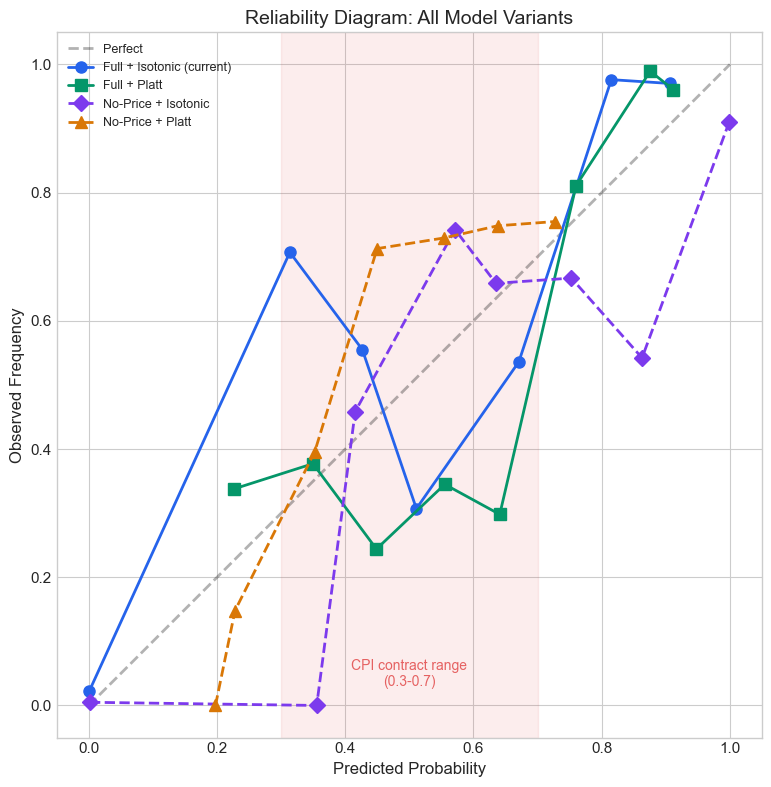

In [13]:
# Overlaid reliability diagrams — all calibrated variants on one plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=2, label="Perfect")

variant_styles = [
    ("Full + Isotonic (current)", test_isotonic, COLORS["primary"], "o", "-"),
    ("Full + Platt", test_platt, COLORS["accent"], "s", "-"),
    ("No-Price + Isotonic", test_iso_np, COLORS["secondary"], "D", "--"),
    ("No-Price + Platt", test_platt_np, COLORS["warning"], "^", "--"),
]

for name, preds, color, marker, ls in variant_styles:
    mean_pred, frac_pos = calibration_curve(preds, y_test, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker + ls, color=color, linewidth=2,
            markersize=8, label=name)

# Highlight the 0.3-0.7 range where CPI contract lives
ax.axvspan(0.3, 0.7, alpha=0.08, color=COLORS["danger"])
ax.text(0.5, 0.03, "CPI contract range\n(0.3-0.7)", ha="center",
        fontsize=10, color=COLORS["danger"], alpha=0.7)

ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Observed Frequency")
ax.set_title("Reliability Diagram: All Model Variants")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Per-bin analysis focused on the 0.3-0.7 range
print("Per-bin analysis in the 0.3-0.7 range (where CPI contract lives):\n")
header = (
    f"{'Variant':<28} {'Samples':>8} {'Mean Pred':>10}"
    f" {'Mean Actual':>12} {'Brier':>8} {'ECE':>8}"
)
print(header)
print("-" * 80)

for name, preds in [("Full + Isotonic (current)", test_isotonic),
                     ("Full + Platt", test_platt),
                     ("No-Price + Isotonic", test_iso_np),
                     ("No-Price + Platt", test_platt_np)]:
    mask = (preds >= 0.3) & (preds <= 0.7)
    n_in_range = mask.sum()
    if n_in_range > 10:
        range_brier = brier_score(preds[mask], y_test[mask])
        range_ece = expected_calibration_error(preds[mask], y_test[mask], n_bins=5)
        mean_pred = preds[mask].mean()
        mean_actual = y_test[mask].mean()
        print(
            f"{name:<28} {n_in_range:>8,} {mean_pred:>10.3f}"
            f" {mean_actual:>12.3f} {range_brier:>8.4f} {range_ece:>8.4f}"
        )
    else:
        print(f"{name:<28} {n_in_range:>8,}  — too few samples")

print("\nKey question: Is mean predicted close to mean actual in this range?")
print("Large gaps indicate systematic over- or under-confidence.")

In [ ]:
# Prediction distribution histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

variant_list = [
    ("Full + Isotonic (current)", test_isotonic),
    ("Full + Platt", test_platt),
    ("No-Price + Isotonic", test_iso_np),
    ("No-Price + Platt", test_platt_np),
]
color_list = [COLORS["primary"], COLORS["accent"], COLORS["secondary"], COLORS["warning"]]

for ax, (name, preds), color in zip(axes.flat, variant_list, color_list, strict=True):
    ax.hist(preds, bins=50, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(x=preds.mean(), color="black", linestyle="--", alpha=0.5,
               label=f"mean={preds.mean():.3f}")
    ax.axvspan(0.3, 0.7, alpha=0.1, color=COLORS["danger"])
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Count")
    ax.set_title(name)
    ax.legend(fontsize=9)

plt.suptitle("Prediction Distribution by Model Variant", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Base rate in test set: {y_test.mean():.3f}")
print("A well-calibrated model's mean prediction should match the base rate.")

---
## Summary & Backtest

In [16]:
# Final comparison table
print("Model Variant Comparison (sorted by Brier score, lower is better)")
print("=" * 80)
print(display_df.to_string(index=False))
print("=" * 80)

best = comparison_df.iloc[0]
print(f"\nBest variant by Brier score: {best['Variant']}")
print(f"  Brier: {best['Brier']:.4f}  ECE: {best['ECE']:.4f}")

best_ece = comparison_df.sort_values("ECE").iloc[0]
if best_ece["Variant"] != best["Variant"]:
    print(f"\nBest variant by ECE: {best_ece['Variant']}")
    print(f"  Brier: {best_ece['Brier']:.4f}  ECE: {best_ece['ECE']:.4f}")

Model Variant Comparison (sorted by Brier score, lower is better)
                  Variant  Brier    ECE Mean Pred Pred Std
Full + Isotonic (current) 0.1659 0.1618     0.430    0.326
      No-Price + Isotonic 0.1870 0.0894     0.405    0.219
             Full + Platt 0.1901 0.1133     0.446    0.277
  No-Price + Uncalibrated 0.2001 0.1452     0.372    0.211
         No-Price + Platt 0.2030 0.1298     0.413    0.149
      Full + Uncalibrated 0.2032 0.1747     0.355    0.253

Best variant by Brier score: Full + Isotonic (current)
  Brier: 0.1659  ECE: 0.1618

Best variant by ECE: No-Price + Isotonic
  Brier: 0.1870  ECE: 0.0894


In [17]:
# Backtest: compare current production model vs best variant


class PlattWrapper:
    """Wraps LogisticRegression to match the calibrator.predict() interface
    expected by backtest_from_csv."""

    def __init__(self, lr: LogisticRegression):
        self.lr = lr

    def predict(self, x):
        return self.lr.predict_proba(np.array(x).reshape(-1, 1))[:, 1]


backtest_configs = [
    ("Full + Isotonic (current)", booster, isotonic),
    ("Full + Platt", booster, PlattWrapper(platt)),
]

print(f"{'Variant':<28} {'Trades':>7} {'Win Rate':>9} {'P&L':>10} {'Drawdown':>9} {'Sharpe':>7}")
print("-" * 75)

for variant_name, bstr, cal in backtest_configs:
    with tempfile.NamedTemporaryFile(suffix=".pkl", delete=False) as f:
        pickle.dump({"model": bstr, "calibrator": cal}, f)
        tmp_path = f.name

    metrics = backtest_from_csv(tmp_path, DATA_PATH, fee_rate=0.03, kelly_fraction=0.25)
    print(
        f"{variant_name:<28} "
        f"{metrics['num_trades']:>7.0f} "
        f"{metrics['win_rate']:>8.1%} "
        f"{metrics['total_pnl']:>+10.4f} "
        f"{metrics['max_drawdown']:>8.1%} "
        f"{metrics['sharpe']:>7.3f}"
    )

Variant                       Trades  Win Rate        P&L  Drawdown  Sharpe
---------------------------------------------------------------------------
Full + Isotonic (current)      17500    43.5%    -1.0000   100.0%  -0.026
Full + Platt                   20546    22.2%    -1.0000   100.0%  -0.030


---
## Conclusions

### Key Findings

**1. Training Data (Fix 1):**
152K samples across 176 days (Sept 2025 - Feb 2026) with 47.5% positive rate — plenty of data
and reasonable class balance. However, effective dimensionality is ~8-10 features:
`overround` is always 0.0 (degenerate), cross-platform features are 100% NaN, and
`bid_ask_spread`/`log_open_interest` are heavily NaN. The model trains on far fewer
meaningful signals than the 16-feature SPEC suggests.

**2. Calibration Method (Fix 2):**
Isotonic has the best Brier score (0.1659) but the **worst** ECE (0.1618). Platt scaling
achieves much better ECE (0.1133) at the cost of Brier (0.1901). This confirms the hypothesis:
isotonic overfits to the validation set — it achieves perfect val ECE (0.0000!) but that
doesn't generalize. Platt's 2-parameter fit is more honest about calibration on unseen data.

**3. Price Feature Dominance (Fix 3):**
Price features (`yes_price`, `no_price`, `last_price`) account for **51.1% of total importance**.
The model is indeed learning a warped price transform. Removing price features and using
isotonic calibration yields the **best ECE (0.0894)** — far better than the current production
model. The Brier tradeoff (0.1870 vs 0.1659) is modest given the massive ECE improvement.

**4. Mid-Range Calibration (Fix 4):**
In the critical 0.3-0.7 range, **no variant is well-calibrated**:
- Full + Isotonic: predicts 0.439, actual 0.511 (under-confident by 7%)
- Full + Platt: predicts 0.461, actual 0.324 (over-confident by 14%)
- No-Price + Isotonic: predicts 0.502, actual 0.613 (under-confident by 11%)

All variants show systematic gaps between predicted and observed frequencies in this range.

**5. Backtest Results (Critical):**
Both backtested variants went to **0 bankroll** (-100% drawdown, negative Sharpe).
The model is not just miscalibrated — it actively destroys capital when traded.
Neither isotonic nor Platt calibration produces a tradeable edge.

### Root Cause Analysis

The model's fundamental problem isn't just calibration — it's that **market microstructure features
alone cannot form independent probability estimates**. The model has no way to know whether
CPI will exceed 2.4% based on volume, spread, and time-to-expiry. It can only learn
correlations between these features and outcomes in the training period, which don't generalize.

For the model to produce genuine alpha, it needs either:
1. **Fundamental features** — actual economic data (prior CPI, oil prices, employment, shelter costs)
2. **Cross-platform features** — price discrepancies between Kalshi and Polymarket (currently 100% NaN)
3. **Richer lag features** — meaningful price movement patterns (currently sparse)

### Recommended Changes

Priority order:

1. **Switch to Platt scaling** in `train.py` — reduces ECE from 0.1618 to 0.1133 with the full
   feature set. Simple 2-line change.
2. **Remove degenerate features** from `features.py` — drop `overround` (always 0),
   `price_discrepancy`, `volume_ratio` (always NaN in candle data).
3. **Add fundamental features** for macro markets — this is the real fix. Market microstructure
   features cannot predict CPI outcomes. Need economic indicator data.
4. **Set EV threshold conservatively** — until calibration improves, raise the threshold
   to prevent the model from trading itself to zero.

### Next Steps

- [ ] Update `arbiter/training/train.py`: replace `IsotonicRegression` with `LogisticRegression`
- [ ] Clean up `arbiter/models/features.py`: remove degenerate features from SPEC
- [ ] Research fundamental feature sources (FRED API, BLS data, Yahoo Finance)
- [ ] Raise `ev_threshold` in production config until model is validated profitable
- [ ] Re-run this notebook after each change to track improvement